### M-DART PAPER: FIGURE 3 AND STATS

In [1]:
# Standard library
import os
import re
import random
import warnings
from pathlib import Path

# Numeric / dataframes
import numpy as np
import pandas as pd

# Stats
import scipy.stats
from scipy.stats import norm
from scipy.optimize import curve_fit
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# Plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerPatch
import seaborn as sns

warnings.filterwarnings('ignore')

In [2]:
### Helper functions
def add_sig_bar(ax, p_val, x1=0, x2=1, y_pad=-0.02, tick_height=0):
    """
    Draw a horizontal significance bar between x1 and x2, with stars above it.

    y_pad: bar height as a fraction of the current y-range, added to the
        current y-max. Negative values (default) place the bar just inside
        the existing plot area; positive values lift it above the current
        top (for bar/box plots that need headroom for a bracket).
    tick_height: length of the vertical end-ticks (bracket ends), as a
        fraction of the current y-range. 0 (default) draws a plain bar with
        no end-ticks. Pass None to auto-size the end-ticks (0.03 * y-range).
    """
    stars = ('****' if p_val < 0.0001 else
             '***'  if p_val < 0.001  else
             '**'   if p_val < 0.01   else
             '*'    if p_val < 0.05   else 'ns')
    y_lo, y_hi = ax.get_ylim()
    y_range    = y_hi - y_lo
    bar_y      = y_hi + y_pad * y_range
    if tick_height is None:
        tick_height = 0.03 * y_range
    ax.plot([x1, x2], [bar_y, bar_y], lw=0.4, color='black', clip_on=False)
    if tick_height:
        ax.plot([x1, x1], [bar_y - tick_height, bar_y], lw=0.4, color='black', clip_on=False)
        ax.plot([x2, x2], [bar_y - tick_height, bar_y], lw=0.4, color='black', clip_on=False)
    ax.text((x1 + x2) / 2, bar_y + 0.001 * y_range, stars,
            ha='center', va='bottom', fontsize=6, color='black')
    ax.set_ylim(y_lo, bar_y + 0.12 * y_range)

### Figure 3, Panel b

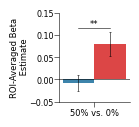

In [3]:
## Load the data
data_path = '../data/figure3/ce_bst_betas_long_c50vs0.csv'
df_50vs0 = pd.read_csv(data_path)
fig_save_path = 'C:\\Users\\psiok\\Box\\3.Projects\\3.MDART-Paper\\MDART_Analyses\\outputs\\figures'

# -----------------------------
# Build summary table
# -----------------------------
# Replace `df_50vs0` with your subject-level dataframe
# Replace `beta` with the column containing the values you want to average
plot_source = df_50vs0.copy()

summary_50vs0 = (
    plot_source
    .groupby(["regressor", "region"])["mean_beta"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)

summary_50vs0["sem"] = (
    summary_50vs0["std"] / np.sqrt(summary_50vs0["n"])
)

# same lower/upper size because SEM is symmetric around the mean
summary_50vs0["err_lower"] = summary_50vs0["sem"]
summary_50vs0["err_upper"] = summary_50vs0["sem"]


# -----------------------------
# Plot
# -----------------------------
plot_df = summary_50vs0.copy()

regions = ["ce", "bst"]
colors = {
    "ce": "#1b6e9c",
    "bst": "#d62626"
}

x_labels = plot_df["regressor"].drop_duplicates().tolist()
x = np.arange(len(x_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(38/25.4, 35/25.4))

for i, region in enumerate(regions):
    sub = plot_df[plot_df["region"] == region].copy()
    sub["regressor"] = pd.Categorical(sub["regressor"], categories=x_labels, ordered=True)
    sub = sub.sort_values("regressor")

    xpos = x + (i - 0.5) * width

    ax.bar(
        xpos,
        sub["mean"],
        width=width,
        label=region,
        color=colors[region],
        alpha=0.85,
    )

    ax.errorbar(
        xpos,
        sub["mean"],
        yerr=[sub["err_lower"], sub["err_upper"]],
        fmt="none",
        color="black",
        linewidth=0.4,
        capsize=1, 
        capthick=0.4,
    )

ax.axhline(0, color="black", linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(["50% vs. 0%"], fontsize=6)
ax.tick_params(axis="x", width=0.4, pad=1)

ax.set_ylim(-0.05, 0.15)
ax.set_yticks([-0.05, 0, 0.05, 0.1, 0.15])
ax.tick_params(axis='y', labelsize=5.8, width=0.4, pad=0.5)

ax.set_ylabel("ROI-Averaged Beta\n Estimate", fontsize=6, labelpad=0)
# ax.set_xlabel("comparison", fontsize=6)
x, y = 1.2, 1.3
# ax.legend(frameon=True, fontsize=3.5, bbox_to_anchor=(x, y), loc='upper right', ncol=2)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.4)
ax.spines["bottom"].set_linewidth(0.4)

plt.tight_layout()

# significance bracket (p=0.003, **)
x_ce  = 0 + (0 - 0.5) * width   # -0.175
x_bst = 0 + (1 - 0.5) * width   #  0.175

bst_row = plot_df[plot_df["region"] == "bst"].iloc[0]
ce_row  = plot_df[plot_df["region"] == "ce"].iloc[0]

y_top = max(
    bst_row["mean"] + bst_row["err_upper"],
    ce_row["mean"]  + ce_row["err_upper"]
) + 0.008

ax.plot(
    [x_ce, x_bst],
    [y_top, y_top],
    color="black", linewidth=0.4
)
ax.text((x_ce + x_bst) / 2, y_top + 0.001, "**", ha="center", va="bottom", fontsize=6)

fig.savefig(os.path.join(fig_save_path, "50vs0_meanBeta.pdf"), bbox_inches='tight')

plt.show()

### Figure 3, Panels c-g

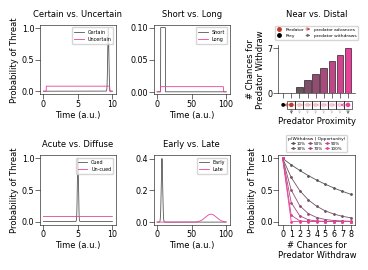

In [4]:
fig = plt.figure(figsize=(90/25.4, 65/25.4))

gs = GridSpec(2, 5, figure=fig,
              width_ratios=[1.2, 0.09, 1.2, 0.28, 1.2],  # last col now matches A/B width
              wspace=0.32, hspace=0.88,  # tightened (was 0.38) to shrink the A/C-B/D gap
              left=0.10, right=0.99, top=0.9, bottom=0.12)

ax_C = fig.add_subplot(gs[0, 0])
ax_D = fig.add_subplot(gs[0, 2])  # shifted by spacer
ax_E = fig.add_subplot(gs[1, 0])
ax_F = fig.add_subplot(gs[1, 2])  # shifted by spacer

gray = '#555555'
pink = '#E8419A'
predator_color = '#C0392B'

def spike(t, loc, scale=0.08):
    pdf = norm.pdf(t, loc=loc, scale=scale)
    return pdf / pdf.max()

# C) Certain vs. Uncertain
t = np.linspace(0, 10, 5000)
ax_C.plot(t, spike(t, loc=9.4, scale=0.08), color=gray, lw=0.6, label='Certain')
ax_C.plot(t, np.where((t <= 9.6) & (t >= 0.4), 0.08, 0), color=pink, lw=0.6, label='Uncertain')
ax_C.set_xlim(0, 10); ax_C.set_ylim(0, 1.0)
ax_C.set_xlabel('Time (a.u.)', fontsize=6, labelpad=1)
ax_C.set_ylabel('Probability of Threat', fontsize=6, labelpad=2)
ax_C.set_title('Certain vs. Uncertain', fontsize=6)
ax_C.set_xticks([0, 5, 10])
ax_C.set_xlim(-0.5, 10.5)
ax_C.set_ylim(-0.05, 1.05)
ax_C.legend(fontsize=3.5, loc='upper right', frameon=True)

# D) Short vs. Long
t = np.linspace(0, 100, 5000)
short = np.where((t >= 5) & (t <= 12), 0.10, 0.0)
ax_D.plot(t, short, color=gray, lw=0.6, label='Short')
ax_D.plot(t, np.where((t <= 96) & (t >= 5), 0.008, 0), color=pink, lw=0.6, label='Long')
ax_D.set_xlim(0, 100); ax_D.set_ylim(0, 0.10)
ax_D.set_xlabel('Time (a.u.)', fontsize=6, labelpad=1)
ax_D.set_title('Short vs. Long', fontsize=6)
ax_D.set_xticks([0, 50, 100])
ax_D.set_xlim(-5, 105)
ax_D.set_ylim(-0.004, 0.104)
ax_D.legend(fontsize=3.5, loc='upper right', frameon=True)

# E) Acute vs. Diffuse
t = np.linspace(0, 10, 5000)
ax_E.plot(t, spike(t, loc=5, scale=0.08), color=gray, lw=0.6, label='Cued')
ax_E.plot(t, np.where((t <= 10) & (t >= 0), 0.08, 0), color=pink, lw=0.6, label='Un-cued')
ax_E.set_xlim(0, 10); ax_E.set_ylim(0, 1.0)
ax_E.set_xlabel('Time (a.u.)', fontsize=6, labelpad=1)
ax_E.set_ylabel('Probability of Threat', fontsize=6, labelpad=2)
ax_E.set_title('Acute vs. Diffuse', fontsize=6)
ax_E.set_xticks([0, 5, 10])
ax_E.set_xlim(-0.5, 10.5)
ax_E.set_ylim(-0.05, 1.05)
ax_E.legend(fontsize=3.5, loc='upper right', frameon=True)

# F) Early vs. Late
t = np.linspace(0, 100, 5000)
early = norm.pdf(t, loc=7, scale=1)
early = early / early.max() * 0.4
late = norm.pdf(t, loc=78, scale=8)
late = late / late.max() * 0.05
ax_F.plot(t, early, color=gray, lw=0.6, label='Early')
ax_F.plot(t, late, color=pink, lw=0.6, label='Late')
ax_F.set_xlim(-0.5, 99.5); ax_F.set_ylim(0, 0.4)
ax_F.set_xlabel('Time (a.u.)', fontsize=6, labelpad=1)
ax_F.set_title('Early vs. Late', fontsize=6)
ax_F.set_xticks([0, 50, 100])
ax_F.set_xlim(-5, 105)
ax_F.set_ylim(-0.016, 0.42)
ax_F.legend(fontsize=3.5, loc='upper right', frameon=True)

# G) Near vs. Distal -- bar + schematic + line plot + legend, flowed top-to-bottom
# inside the full last column (gs[0,4] + gs[1,4] combined), positioned by measured extents
n_boxes = 8
box_h = 1.0
faint_alpha = 0.25

states = np.arange(0, 9)
p_values = [0.10, 0.30, 0.50, 0.70, 0.90, 1.00]
approach_cmap = LinearSegmentedColormap.from_list('approach_cmap', [pink, gray])
approach_colors = [approach_cmap(1 - i / (len(p_values) - 1)) for i in range(len(p_values))]

pos_top_cell = gs[0, 4].get_position(fig)
pos_bot_cell = gs[1, 4].get_position(fig)

# widen panel E by reclaiming part of the D-E gap (the dedicated spacer column
# plus its wspace padding), down to the same gap width already used between
# A/C and B/D, so the schematic's boxes can render larger
pos_D = gs[0, 2].get_position(fig)
pos_A = gs[0, 0].get_position(fig)
ab_gap = gs[0, 2].get_position(fig).x0 - pos_A.x1
col_right = pos_top_cell.x1
col_top = pos_top_cell.y1
col_bottom = pos_bot_cell.y0
be_gap = ab_gap + 0.031  # smaller offset than before: col3 width kept intact after widening the A/C-B/D gap
col_left = pos_D.x1 + be_gap
col_w = col_right - col_left
gap = 0.02  # figure-fraction gap kept below the legend, above the bar plot

def tight_bottom(artist):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    if hasattr(artist, 'get_tightbbox'):
        bbox = artist.get_tightbbox(renderer)
    else:
        bbox = artist.get_window_extent(renderer)
    return bbox.transformed(fig.transFigure.inverted())

box_centers = [(i + 0.5, box_h / 2) for i in range(n_boxes)]
n_chances = list(range(1, n_boxes + 1))  # 1..8 left to right, matching bar/tick order

# ---- Title: fixed at the same height as the other panels' titles (aligned with
# "Short vs. Long"), independent of whatever ends up below it ----
fig.canvas.draw()
renderer_align = fig.canvas.get_renderer()
b_title_bbox = ax_D.title.get_window_extent(renderer_align).transformed(fig.transFigure.inverted())
title_y_center = (b_title_bbox.y0 + b_title_bbox.y1) / 2
top_center_x = col_left + col_w / 2
near_distal_title = fig.text(top_center_x, title_y_center, 'Near vs. Distal',
                              fontsize=6, ha='center', va='center')
title_bottom = tight_bottom(near_distal_title).y0

# ---- Legend: right below the title -- Predator/Prey/arrow-style proxies ----
class HandlerArrow(HandlerPatch):
    def __init__(self, arrow_color, **kw):
        super().__init__(**kw)
        self.arrow_color = arrow_color

    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                        width, height, fontsize, trans):
        p = mpatches.FancyArrowPatch((0, 0.5 * height), (width, 0.5 * height),
                                      arrowstyle='->', mutation_scale=4.5,
                                      color=self.arrow_color, lw=0.6,
                                      shrinkA=0, shrinkB=0)
        p.set_transform(trans)
        return [p]

predator_dot = Line2D([0], [0], marker='o', markersize=3.5, linestyle='None',
                       markerfacecolor=predator_color, markeredgecolor='none',
                       label='Predator')
prey_dot = Line2D([0], [0], marker='o', markersize=3.5, linestyle='None',
                   markerfacecolor='black', markeredgecolor='none', label='Prey')
advance_handle = mpatches.FancyArrowPatch((0, 0), (1, 0), color=predator_color,
                                           label='predator advances')
withdraw_handle = mpatches.FancyArrowPatch((0, 0), (1, 0), color=gray,
                                            label='predator withdraws')

legend_elements = [predator_dot, prey_dot, advance_handle, withdraw_handle]
leg_top = fig.legend(handles=legend_elements, loc='upper center',
                      bbox_to_anchor=(top_center_x, col_top),
                      bbox_transform=fig.transFigure, ncol=2, fontsize=3.2, frameon=True,
                      handlelength=1.0, columnspacing=0.5, borderaxespad=0.15,
                      handler_map={advance_handle: HandlerArrow(predator_color),
                                   withdraw_handle: HandlerArrow(gray)})

legend_bottom = tight_bottom(leg_top).y0

circle_alphas = [1.0] + [faint_alpha] * (n_boxes - 2) + [1.0]

# ---- Bar plot: placed right below the legend's real (measured) bottom edge ----
bar_h_guess = 0.19  # shorter than before to keep the axis-schematic clear of the line plot legend
ax_bar = fig.add_axes([col_left, legend_bottom - gap - bar_h_guess,
                        col_w, bar_h_guess])

bar_x = [c[0] for c in box_centers]
prey_xy_axis = (-0.5, box_h / 2)  # shared with the axis-schematic below, so ticks line up exactly
bar_heights = [c - 1 for c in n_chances]  # remaining chances to withdraw: proximity=1 -> 0 left, proximity=8 -> 7 left
bar_colors = [approach_cmap((n_boxes - c) / (n_boxes - 1)) for c in n_chances]  # gray at proximity=1, pink at proximity=8

ax_bar.bar(bar_x, bar_heights, width=0.8, color=bar_colors, edgecolor='black', linewidth=0.4)
ax_bar.set_xlim(-1.1, n_boxes + 0.4)  # left margin widened for the mirrored axis-schematic's prey icon
ax_bar.set_ylim(0, n_boxes - 1 + 0.5)
ax_bar.set_yticks([0, n_boxes - 1])
ax_bar.set_xticks([prey_xy_axis[0]] + bar_x)  # 0 = prey, 1-8 = each box, matching the schematic below
ax_bar.tick_params(axis='x', labelbottom=False)  # keep tick marks, hide numbers -- schematic below is the label
ax_bar.set_ylabel('# Chances for\nPredator Withdraw', fontsize=6, labelpad=2)
ax_bar.tick_params(axis='both', labelsize=5.5, width=0.4, pad=0.5)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.spines['bottom'].set_linewidth(0.4)
ax_bar.spines['left'].set_linewidth(0.4)

bar_bottom = tight_bottom(ax_bar).y0

predator_cmap = LinearSegmentedColormap.from_list('predator_cmap', [predator_color, pink])  # red near prey (left) -> pink at state 8 (right)
predator_colors_by_box = [predator_cmap(i / (n_boxes - 1)) for i in range(n_boxes)]

# ---- Axis schematic: replaces the bar plot's numeric x-axis. Boxes reuse the
# same x-positions as bar_x, so each box lines up under its bar. Mirrored
# relative to the schematic above: prey on the left (proximity=1, 0 chances
# left), red advance arrows point left (toward prey), gray withdraw arrows
# point down (away from the bar plot above, not back into it) ----
axis_sch_gap = 0.001  # tight, so each tick mark visually points to its box below
axis_sch_h_guess = 0.065  # slightly shorter, lifts the schematic up a bit to make room for the label below
ax_axis_sch = fig.add_axes([col_left, bar_bottom - axis_sch_gap - axis_sch_h_guess,
                             col_w, axis_sch_h_guess])

axis_step_targets = [prey_xy_axis] + box_centers[:-1]

for b in range(n_boxes):
    ax_axis_sch.add_patch(mpatches.Rectangle((b, 0), 1, box_h, fill=False,
                                              edgecolor='black', linewidth=0.4))

for (x, y), a, pc in zip(box_centers, circle_alphas, predator_colors_by_box):
    ax_axis_sch.add_patch(mpatches.Circle((x, y), radius=0.28, facecolor=pc,
                                           edgecolor='none', alpha=a, zorder=5))

ax_axis_sch.add_patch(mpatches.Circle(prey_xy_axis, radius=0.24, facecolor='black',
                                       edgecolor='none', zorder=5))

for (x0, y0), (x1, y1), a, pc in zip(box_centers, axis_step_targets, circle_alphas, predator_colors_by_box):
    ax_axis_sch.annotate('', xy=(x1 + 0.06, y1), xytext=(x0 - 0.06, y0),
                          arrowprops=dict(arrowstyle='->', color=pc,
                                          lw=0.5, alpha=a, mutation_scale=5,
                                          shrinkA=0, shrinkB=0))
    ax_axis_sch.annotate('', xy=(x0, -0.62), xytext=(x0, -0.02),
                          arrowprops=dict(arrowstyle='->', color=gray, lw=0.45, alpha=a,
                                          mutation_scale=4.5, shrinkA=0, shrinkB=0))

ax_axis_sch.set_xlim(-1.1, n_boxes + 0.4)
ax_axis_sch.set_ylim(-0.75, box_h + 0.1)
ax_axis_sch.set_aspect('equal')
ax_axis_sch.axis('off')

axis_sch_bottom = tight_bottom(ax_axis_sch).y0

# ---- Predator Proximity caption: placed right below the schematic's real
# measured bottom edge (which already includes the downward arrows), so it
# can't overlap them regardless of exact spacing ----
proximity_label_gap = 0.006
proximity_label = fig.text(col_left + col_w / 2, axis_sch_bottom - proximity_label_gap,
                            'Predator Proximity', fontsize=6, ha='center', va='top')

# ---- Line plot: same size and position as row 1's panels (Acute vs. Diffuse /
# Early vs. Late), with the p-value legend inset like the other panels' legends ----
ax_mid = fig.add_axes([col_left, pos_bot_cell.y0, col_w,
                        pos_bot_cell.y1 - pos_bot_cell.y0])

for p, color, label in zip(p_values, approach_colors, ['10%', '30%', '50%', '70%', '90%', '100%']):
    p_threat = (1 - p) ** states
    ax_mid.plot(states, p_threat, lw=0.6, label=label, color=color, marker='o', markersize=1)

ax_mid.set_xlim(-0.5, 8.5)
ax_mid.set_ylim(-0.05, 1.05)
ax_mid.set_xlabel('# Chances for\nPredator Withdraw', fontsize=6, labelpad=1)
ax_mid.set_ylabel('Probability of Threat', fontsize=6, labelpad=2)
ax_mid.set_xticks(np.arange(0, 9))
ax_mid.set_yticks([0, 0.5, 1])

leg = ax_mid.legend(title='p(Withdraw | Opportunity)', title_fontsize=3.2, fontsize=3,
                     loc='lower center', bbox_to_anchor=(0.5, 1.04), ncol=3, frameon=True,
                     borderaxespad=0.15, handlelength=1.0, columnspacing=0.5,
                     labelspacing=0.2, handletextpad=0.4)
leg.get_title().set_multialignment('center')

all_axes = [ax_C, ax_D, ax_E, ax_F, ax_bar, ax_mid]
for ax in all_axes:
    ax.tick_params(axis='both', labelsize=5.8, width=0.4, pad=0.5)
    ax.spines['top'].set_linewidth(0.4)
    ax.spines['bottom'].set_linewidth(0.4)
    ax.spines['left'].set_linewidth(0.4)
    ax.spines['right'].set_linewidth(0.4)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

fig.savefig(os.path.join(fig_save_path, 'embed_test_full_figure.png'), dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(fig_save_path, 'conceptual_figures_with_bar_plot_final.pdf'), bbox_inches='tight', transparent=True)
plt.show()


### Figure 3, Panels h-j

In [5]:
# 1. Load & filter
df_path = "../data/figure3/ce_bst_betas_long_cueType.csv"
df = pd.read_csv(df_path)

# Keep only risk probability regressors: p000_c0 … p100_c0
# Exclude ambiguity (p005_amb_c0, p010_amb_c0, …)
risk_pattern = re.compile(r'^p(\d{3})_c0$')

def extract_p(reg):
    m = risk_pattern.match(reg)
    return int(m.group(1)) if m else None

df['p'] = df['regressor'].apply(extract_p)
df_risk = df.dropna(subset=['p']).copy()
df_risk['p'] = df_risk['p'].astype(float)
df_risk = df_risk.rename(columns={'mean_beta': 'Beta', 'subject': 'subj'})
df_risk['Region'] = df_risk['region'].replace({'ce': 'Ce', 'bst': 'BST'})

# 2. Sigmoid definition (anchored standard sigmoid)
def sigmoid_anchored_standard(x, L, k, x0, min_x, min_y):
    sigmoid_at_min = L / (1 + np.exp(-k * (min_x - x0)))
    offset = min_y - sigmoid_at_min
    return L / (1 + np.exp(-k * (x - x0))) + offset

# 3. Bootstrap sigmoid fitting (1000 iterations)
N_BOOT = 1000 ## POINT 1 ini200
random.seed(51)
np.random.seed(51)

popt_df_list   = []
smooth_df_list = []

for roi_name in ['BST', 'Ce']:
    sub_df     = df_risk[df_risk['Region'] == roi_name]
    x_data     = sub_df['p'].values
    y_data     = sub_df['Beta'].values
    y_data = (y_data - np.mean(y_data[x_data==0])) / (np.mean(y_data[x_data==100])-np.mean(y_data[x_data==0]))
    subj_data  = sub_df['subj'].values
    subj_list  = list(sub_df['subj'].unique())
    x_smooth   = np.linspace(x_data.min(), x_data.max(), 200)

    popt_records  = []
    smooth_curves = []
    n_success = 0
    n_fail    = 0

    for _ in range(N_BOOT):
        idx_subjs  = np.random.choice(subj_list, size=len(subj_list) // 2, replace=True) # random.sample vs random.choices? POINT 2
        mask       = np.isin(subj_data, idx_subjs)
        x_sub, y_sub = x_data[mask], y_data[mask]

        min_x = x_sub.min()
        min_y = np.median(y_sub[x_sub == min_x]) # mean vs median? POINT 3
        max_x = x_sub.max()
        # L     = np.median(y_sub[x_sub == max_x]) - min_y # mean vs median? POINT 4
        # L     = y_sub.max() - min_y
        L     = 1.0 # since we normalized y to [0,1], the max should be 1.0
        def _wrapper(x, k, x0, _min_x=min_x, _min_y=min_y, _L=L):
            return sigmoid_anchored_standard(x, _L, k, x0, _min_x, _min_y)

        try:
            popt, _ = curve_fit(_wrapper, x_sub, y_sub,
                                p0=[0.1, 50], maxfev=10000) # initial guess for k and x0: POINT 5 [0.5, 50]
            popt_records.append({'k': popt[0], 'x0': popt[1]})
            smooth_curves.append(_wrapper(x_smooth, *popt) - min_y)
            n_success += 1
        except RuntimeError:
            n_fail += 1
            pass

    print(f"{roi_name}: {n_success}/{N_BOOT} iterations converged, {n_fail} failed")

    # Collect smooth curves
    smooth_arr = np.array(smooth_curves)           # shape (n_successful, 200)
    for boot_i, curve in enumerate(smooth_arr):
        smooth_df_list.append(
            pd.DataFrame({'x': x_smooth, 'y_smooth': curve,
                          'idx': boot_i, 'Region': roi_name})
        )

    # Collect parameters
    popt_df_roi = pd.DataFrame(popt_records)
    popt_df_roi['Region'] = roi_name
    popt_df_list.append(popt_df_roi)

smooth_df = pd.concat(smooth_df_list, ignore_index=True)
popt_df   = pd.concat(popt_df_list,  ignore_index=True)

# 4. Statistics
BST_k  = popt_df.loc[popt_df['Region'] == 'BST', 'k']
Ce_k   = popt_df.loc[popt_df['Region'] == 'Ce',  'k']
BST_x0 = popt_df.loc[popt_df['Region'] == 'BST', 'x0']
Ce_x0  = popt_df.loc[popt_df['Region'] == 'Ce',  'x0']

mu_k  = scipy.stats.mannwhitneyu(BST_k,  Ce_k,  nan_policy='omit', alternative='two-sided')
mu_x0 = scipy.stats.mannwhitneyu(BST_x0, Ce_x0, nan_policy='omit', alternative='two-sided')

print(f"Mann-Whitney U  k : U={mu_k[0]:.0f},  p={mu_k[1]:.4f}")
print(f"Mann-Whitney U x0 : U={mu_x0[0]:.0f}, p={mu_x0[1]:.4f}")

BST: 1000/1000 iterations converged, 0 failed
Ce: 1000/1000 iterations converged, 0 failed
Mann-Whitney U  k : U=543695,  p=0.0007
Mann-Whitney U x0 : U=193918, p=0.0000


In [6]:
# Load the bootstrapped sigmoid-fit results actually used to generate
# Fig. 3h-j and the reported statistics (seed=51). Loaded from disk rather
# than using the fresh bootstrap computed in the cell above, because scipy's
# curve_fit optimizer is not guaranteed to converge identically across
# scipy/numpy versions or platforms even with the same random seed -- a
# fresh re-run could silently produce slightly different fitted curves/stats.
smooth_df = pd.read_csv("../data/figure3/smooth_df_seed51.csv")
popt_df = pd.read_csv("../data/figure3/popt_df_seed51.csv")

#### Fig. 3h and i

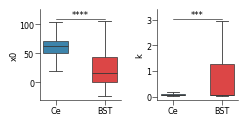

In [7]:
# Box plots: x0 and k
f2  = plt.figure(figsize=(65/25.4, 30/25.4))
gs2 = f2.add_gridspec(1, 2, wspace=0.45)
ax2 = f2.add_subplot(gs2[0])
ax3 = f2.add_subplot(gs2[1])

palette = {'Ce': "#1b6e9c", 'BST': "#d62626"}
order   = ['Ce', 'BST']

# --- ax2: x0 box plot ---
# saturation=1: sns.boxplot desaturates palette colors by default (toward
# gray) before filling boxes, so the box fill never actually matched the
# literal palette hex. Disabling that here, then matching alpha to the
# Fig. 3k bar plot below, makes both panels render the exact same RGBA.
sns.boxplot(x='Region', y='x0', data=popt_df, ax=ax2, saturation=1,
            palette=palette, order=order, width=0.5, linewidth=0.6, showfliers=False)
if ax2.get_legend(): ax2.get_legend().remove()
ax2.set_xlabel(' ', fontsize=6, labelpad=1)
ax2.set_ylabel('x0', fontsize=6, labelpad=0)
ax2.margins(x=0.05)

# --- ax3: k box plot ---
sns.boxplot(x='Region', y='k', data=popt_df, ax=ax3, saturation=1,
            palette=palette, order=order, width=0.5, linewidth=0.6, showfliers=False)
if ax3.get_legend(): ax3.get_legend().remove()
ax3.set_xlabel(' ', fontsize=6, labelpad=1)
ax3.set_ylabel('k', fontsize=6, labelpad=1.5)
ax3.margins(x=0.05)

for ax in [ax2, ax3]:
    # Match Fig. 3k's ax.bar(..., alpha=0.85) so the box fill and bar fill
    # are the identical RGBA, not just the identical hue.
    for patch in ax.patches:
        patch.set_alpha(0.85)
    ax.tick_params(axis='both', labelsize=5.8, pad=0.5, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines["left"].set_linewidth(0.4)
    ax.spines["bottom"].set_linewidth(0.4)

# --- significance bars (after violins so ylim is already set) ---
add_sig_bar(ax2, p_val=0.0000)  # x0: p<0.0001 → ****
add_sig_bar(ax3, p_val=0.0007)  # k:  p<0.001   → ***

plt.tight_layout()
plt.savefig(os.path.join(fig_save_path, 'Fig3_boxplots_x0_k_with_stars.pdf'), dpi=None, bbox_inches='tight')
plt.show()


#### Fig. 3j

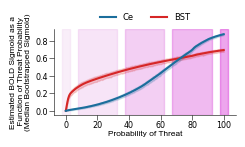

In [8]:
# Sigmoid line plot only
f1  = plt.figure(figsize=(65/25.4, 40/25.4))
ax1 = f1.add_subplot(111)

palette = {'Ce': "#1b6e9c", 'BST': "#d62626"}

# --- shaded probability bands (add before lineplot call) ---
shade_alpha = 0.35

shade_ranges = [
    (-2.5, 2.5),    # "at 0"
    (7.5,  32.5),
    (37.5,  62.5),
    (67.5,  92.5),
    (97.5,  102.5),  # "at 100"
]

colors = ['#eed1ee', '#e9b4e9', '#df77df', '#d63bd6', '#cc00cc']  # 0%, 10-30%, 40-60%, 70-90%, 100%

for i, (xmin, xmax) in enumerate(shade_ranges):
    ax1.axvspan(xmin, xmax, color=colors[i], alpha=shade_alpha, zorder=0)

# --- ax1: sigmoid curves ---
sns.lineplot(x='x', y='y_smooth', data=smooth_df, hue='Region',
             ax=ax1, errorbar=('ci', 99.9), legend=True, palette=palette)
handles, labels = ax1.get_legend_handles_labels()
order_idx = [labels.index('Ce'), labels.index('BST')]  # desired order
ax1.legend(
    [handles[i] for i in order_idx],
    [labels[i]  for i in order_idx],
    loc='lower center', bbox_to_anchor=(.5, 1),
    ncol=2, frameon=False, fontsize=6
)

ax1.set_xlabel('Probability of Threat', fontsize=6, family='arial', labelpad=1)
ax1.set_ylabel('Estimated BOLD Sigmoid as a\n Function of Threat Probability\n(Median Bootstrapped Sigmoid)',
               fontsize=6, labelpad=3, family='arial')
ax1.margins(x=0.05)

ax1.tick_params(axis='both', labelsize=5.8, pad=0.5, width=0.4)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines["left"].set_linewidth(0.4)
ax1.spines["bottom"].set_linewidth(0.4)

plt.tight_layout()
plt.savefig(os.path.join(fig_save_path, 'Fig3_sigmoid_lineplot.pdf'), dpi=300, bbox_inches='tight')
plt.show()


### Figure 3, Panel k

In [9]:
path_contrasts = "../data/figure3/contrasts_group_summary.csv"
df_contrasts = pd.read_csv(path_contrasts)

#### First step of panel k

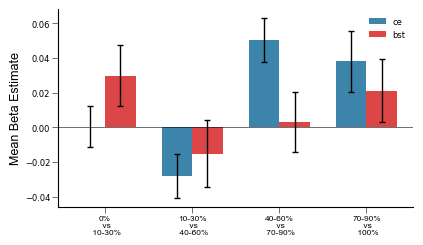

In [10]:
regressor_order = [
    '10-30% vs 0%',
    '40-60% vs 10-30%',
    '70-90% vs 40-60%',
    '100% vs 70-90%',
]

display_labels = [
    '0%\n vs\n 10-30%',
    '10-30%\n vs\n 40-60%',
    '40-60%\n vs\n 70-90%',
    '70-90%\n vs\n 100%',
]

regressors = [r for r in regressor_order if r in df_contrasts['regressor'].values]
x     = np.arange(len(regressors))
width = 0.35

colors = {'ce': "#1b6e9c", 'bst': "#d62626"}
mm  = 1 / 25.4
fig, ax = plt.subplots(figsize=(110*mm, 65*mm))

for region, offset in zip(['ce', 'bst'], [-width/2, width/2]):
    sub      = df_contrasts[df_contrasts['region'] == region].set_index('regressor').loc[regressors]
    means    = sub['mean'].values
    err_low  = means - sub['ci68_lower'].values
    err_high = sub['ci68_upper'].values - means

    ax.bar(x + offset, means, width, label=region, color=colors[region], alpha=0.85)
    ax.errorbar(x + offset, means,
                yerr=[err_low, err_high],
                fmt='none', color='black', capsize=2, linewidth=1)

ax.axhline(0, color='black', linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels(display_labels, fontsize=6, fontfamily='arial')
# ax.set_xlabel('Comparison', fontsize=9, labelpad=2, fontfamily='arial')
ax.set_ylabel('Mean Beta Estimate',  fontsize=9, labelpad=2, fontfamily='arial')
ax.tick_params(axis='x', labelsize=6, length=4, width=0.4, pad=2, rotation=0)
ax.tick_params(axis='y', labelsize=6, length=4, width=0.4, pad=2)
ax.legend(frameon=False, fontsize=6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(fig_save_path, 'Fig3_bst_ce_contrasts_mean_beta.png'), bbox_inches='tight')
plt.show()


### Fig. 3k

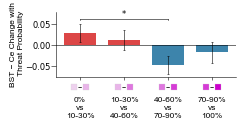

In [11]:
# Pivot to wide, compute difference and propagated SE
bst = df_contrasts[df_contrasts['region'] == 'bst'].set_index('regressor')
ce  = df_contrasts[df_contrasts['region'] == 'ce'].set_index('regressor')

diff_mean = bst.loc[regressors, 'mean'].values - ce.loc[regressors, 'mean'].values
se_diff   = np.sqrt(bst.loc[regressors, 'sem'].values**2 + ce.loc[regressors, 'sem'].values**2)
ci68_low  = diff_mean - se_diff
ci68_high = diff_mean + se_diff

x  = np.arange(len(regressors)) * 0.7
mm = 1 / 25.4
fig, ax = plt.subplots(figsize=(65*mm, 45*mm))  # slightly taller to fit the custom labels

bar_colors = [colors['bst'] if v >= 0 else colors['ce'] for v in diff_mean]
ax.bar(x, diff_mean, 0.5, color=bar_colors, alpha=0.85)
ax.errorbar(x, diff_mean,
            yerr=[diff_mean - ci68_low, ci68_high - diff_mean],
            fmt='none', color='black', capsize=1, capthick=0.4, linewidth=0.4)

ax.axhline(0, color='black', linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels([])              # default text labels removed, replaced below
ax.tick_params(axis='x', length=2, width=0.4, pad=0.5)
ax.set_xlabel('', fontsize=6, labelpad=2, fontfamily='arial')
ax.set_ylabel('BST − Ce Change with\n Threat Probability', fontsize=6, labelpad=1, fontfamily='arial')
ax.tick_params(axis='y', labelsize=6, width=0.4, pad=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["left"].set_linewidth(0.4)
ax.spines["bottom"].set_linewidth(0.4)

# --- significance bracket: bar 1 (10-30% vs 0%) vs bar 3 (70-90% vs 40-60%) ---
add_sig_bar(ax, 0.0288, x1=x[0], x2=x[2], y_pad=0.05, tick_height=None)

# --- custom labels: 2 color squares + 3 text lines, centered under each bar ---
bin_shades  = ['#eed1ee', '#e9b4e9', '#df77df', '#d63bd6', '#cc00cc']  # 0%, 10-30%, 40-60%, 70-90%, 100%
label_lines = [lab.split('\n') for lab in display_labels]  # e.g. ['0%', ' vs', ' 10-30%']

trans    = ax.get_xaxis_transform()  # x in data coords, y in axes-fraction coords
sq_y     = -0.16   # vertical position of the squares
sq_off   = 0.09    # horizontal offset of each square from the bar center
text_y0  = -0.30   # vertical position of the first text line
line_gap = 0.13    # vertical spacing between text lines

for i in range(len(regressors)):
    ax.plot(x[i] - sq_off, sq_y, marker='s', markersize=4.5,
            color=bin_shades[i], markeredgecolor='#d0d2d3', markeredgewidth=0.2,
            transform=trans, clip_on=False, linestyle='None')
    ax.plot(x[i] + sq_off, sq_y, marker='s', markersize=4.5,
            color=bin_shades[i + 1], markeredgecolor='#d0d2d3', markeredgewidth=0.2,
            transform=trans, clip_on=False, linestyle='None')
    ax.text(x[i], sq_y, '–', ha='center', va='center', fontsize=6,
            transform=trans, clip_on=False)
    for j, line in enumerate(label_lines[i]):
        ax.text(x[i], text_y0 - j * line_gap, line.strip(),
                ha='center', va='top', fontsize=6, fontfamily='arial',
                transform=trans, clip_on=False)


plt.tight_layout()
plt.savefig(os.path.join(fig_save_path, 'Fig3_bst_ce_contrasts_diff_mean_beta_with_stars.pdf'), bbox_inches='tight')
plt.show()

#### Stats for panel k:

In [12]:
# --- Load data ---
csv_path = Path("../data/figure3/contrasts_subject_level.csv")
df = pd.read_csv(csv_path)

# Pivot to one column per region, compute BST - CE per subject/regressor
wide = df.pivot(index=["subject", "regressor"], columns="region", values="mean_beta").reset_index()
wide["bst_minus_ce"] = wide["bst"] - wide["ce"]

# Reshape the difference score back into long format and append to original df
diff_long = wide[["subject", "regressor", "bst_minus_ce"]].rename(columns={"bst_minus_ce": "mean_beta"})
diff_long["region"] = "bst_minus_ce"
df_full = pd.concat([df, diff_long[["subject", "regressor", "region", "mean_beta"]]], ignore_index=True)

# Keep contrasts in natural order; reference = lowest-probability contrast
regressor_order = ["10-30% vs 0%", "40-60% vs 10-30%", "70-90% vs 40-60%", "100% vs 70-90%"]
diff_df = df_full[df_full["region"] == "bst_minus_ce"].copy()
diff_df["regressor"] = pd.Categorical(diff_df["regressor"], categories=regressor_order, ordered=True)

# --- Mixed-effects model: BST-CE difference ~ regressor (subject random intercept) ---
model = smf.mixedlm("mean_beta ~ C(regressor)", data=diff_df, groups=diff_df["subject"])
result = model.fit()
print(result.summary())


def level_value_contrast(result, level, reference=regressor_order[0]):
    """Row vector testing whether `level`'s value equals zero
    (Intercept, or Intercept + coef for non-reference levels)."""
    names = result.model.exog_names
    vec = np.zeros(len(names))
    vec[names.index("Intercept")] = 1
    if level != reference:
        vec[names.index(f"C(regressor)[T.{level}]")] = 1
    return vec.reshape(1, -1)


def pairwise_diff_contrast(result, level_a, level_b, reference=regressor_order[0]):
    """Row vector testing level_a's effect minus level_b's effect (each relative to `reference`)."""
    names = result.model.exog_names
    vec = np.zeros(len(names))
    if level_a != reference:
        vec[names.index(f"C(regressor)[T.{level_a}]")] += 1
    if level_b != reference:
        vec[names.index(f"C(regressor)[T.{level_b}]")] -= 1
    return vec.reshape(1, -1)


# ============================================================
# 1) Each bar (regressor) tested against zero
# ============================================================
rows = []
for level in regressor_order:
    c = level_value_contrast(result, level)
    tt = result.t_test(c)
    rows.append({
        "regressor": level,
        "coef": float(tt.effect),
        "std_err": float(tt.sd),
        "z": float(tt.tvalue),
        "p_raw": float(tt.pvalue),
    })

vs_zero = pd.DataFrame(rows)
vs_zero["reject_holm"], vs_zero["p_holm"] = multipletests(vs_zero["p_raw"], method="holm")[:2]
vs_zero.round(4)
print("BST-CE difference vs zero (per bar):")
print(vs_zero)


# ============================================================
# 2) ANOVA (regressor effect)
# ============================================================
anova_table = sm.stats.anova_lm(smf.ols("mean_beta ~ C(regressor)", data=diff_df).fit(), typ=3)
print("ANOVA table:")
print(anova_table)


# ============================================================
# 3) Pairwise comparisons between bars
# ============================================================
reference = regressor_order[0]  # "10-30% vs 0%"

rows = []
for level_b in regressor_order[1:]:
    c = pairwise_diff_contrast(result, reference, level_b)
    tt = result.t_test(c)
    rows.append({
        "comparison": f"{reference} vs {level_b}",
        "coef": float(tt.effect),
        "std_err": float(tt.sd),
        "z": float(tt.tvalue),
        "p_raw": float(tt.pvalue),
    })

pairwise = pd.DataFrame(rows)
pairwise["reject_holm"], pairwise["p_holm"] = multipletests(pairwise["p_raw"], method="holm")[:2]
pairwise.round(4)

                   Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       mean_beta
No. Observations:         404           Method:                   REML     
No. Groups:               101           Scale:                    0.0442   
Min. group size:          4             Log-Likelihood:           46.9845  
Max. group size:          4             Converged:                Yes      
Mean group size:          4.0                                              
---------------------------------------------------------------------------
                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                         0.029    0.021  1.408 0.159 -0.012  0.070
C(regressor)[T.40-60% vs 10-30%] -0.017    0.030 -0.562 0.574 -0.075  0.041
C(regressor)[T.70-90% vs 40-60%] -0.077    0.030 -2.590 0.010 -0.135 -0.019
C(regressor)[T.100% vs 70-90%] 

,comparison,coef,std_err,z,p_raw,reject_holm,p_holm
0,10-30% vs 0% vs 40-60% vs 10-30%,0.0166,0.0296,0.5617,0.5743,False,0.5743
1,10-30% vs 0% vs 70-90% vs 40-60%,0.0766,0.0296,2.5902,0.0096,True,0.0288
2,10-30% vs 0% vs 100% vs 70-90%,0.0464,0.0296,1.5668,0.1172,False,0.2343


In [13]:
anova_table = sm.stats.anova_lm(smf.ols("mean_beta ~ C(regressor, Treatment('100% vs 70-90%'))", data=diff_df).fit(), typ=3)
print("ANOVA table:")
print(anova_table)

ANOVA table:
                                              sum_sq     df         F  \
Intercept                                   0.028838    1.0  0.652395   
C(regressor, Treatment('100% vs 70-90%'))   0.345924    3.0  2.608571   
Residual                                   17.681412  400.0       NaN   

                                             PR(>F)  
Intercept                                  0.419738  
C(regressor, Treatment('100% vs 70-90%'))  0.051246  
Residual                                        NaN  
